In [5]:
# 导入基础库
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 可视化风格设置
try:
    plt.style.use('seaborn')
except OSError:
    try:
        plt.style.use('seaborn') # 兼容旧版 matplotlib
    except OSError:
        pass # 如果连 seaborn 也没有就算了
sns.set(font_scale=1.1)

# 读取D已经加工好的增强数据（相对当前笔记本所在目录）
train_path = 'data/train_augmented_D.csv'
test_path = 'data/test_augmented_D.csv'

train_df = pd.read_csv(train_path)
test_df = pd.read_csv(test_path)

print('训练集维度:', train_df.shape)
print('测试集维度:', test_df.shape)
print('训练集列示例:', train_df.columns[:10].tolist(), '...')

train_df.head()

训练集维度: (221, 41)
测试集维度: (95, 39)
训练集列示例: ['event_id', 'num_perimeters_0_5h', 'dt_first_last_0_5h', 'low_temporal_resolution_0_5h', 'area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'log1p_area_first', 'log1p_growth'] ...


,event_id,num_perimeters_0_5h,dt_first_last_0_5h,low_temporal_resolution_0_5h,area_first_ha,area_growth_abs_0_5h,area_growth_rel_0_5h,area_growth_rate_ha_per_h,log1p_area_first,log1p_growth,...,along_track_speed,event_start_hour,event_start_dayofweek,event_start_month,time_to_hit_hours,event,projected_time_to_threat,kinetic_momentum,directed_speed_vector,initial_vigor_index
0,10892457,3,4.265188,0,79.696304,2.875935,0.036086,0.674281,4.390693,1.354787,...,-0.106026,19,4,5,18.892512,0,3.178217e+03,0.049058,-0.106026,5.948453
1,11757157,2,1.169918,0,8.946749,0.000000,0.000000,0.000000,2.297246,0.000000,...,-0.000000,4,4,6,22.048108,1,2.930926e+09,0.000000,-0.000000,0.000000
2,11945086,4,4.777526,0,106.482638,0.000000,0.000000,0.000000,4.677329,0.000000,...,0.000000,22,4,8,0.888895,1,3.272375e+09,0.000000,0.000000,0.000000
3,12044083,1,0.000000,1,67.631125,0.000000,0.000000,0.000000,4.228746,0.000000,...,0.000000,20,5,8,60.953021,0,6.411987e+10,0.000000,0.000000,0.000000
4,12052347,2,4.975273,0,35.632874,0.000000,0.000000,0.000000,3.600946,0.000000,...,0.000000,21,5,7,44.990274,0,1.800543e+10,0.000000,0.000000,0.000000


## 1. 初始0-5小时特征分布与趋势（配合D的深度特征工程）

这里主要关注0-5小时内与火场几何变化和运动相关的原始特征，例如：
- `area_first_ha`, `area_growth_abs_0_5h`, `area_growth_rate_ha_per_h` 等面积增长指标；
- `radial_growth_m`, `radial_growth_rate_m_per_h` 等火线外扩速度；
- `centroid_displacement_m`, `centroid_speed_m_per_h` 等火场质心移动速度；
- `dist_min_ci_0_5h` 等与社区最近距离相关指标。

In [6]:
# 选取与0-5小时相关的核心特征列
early_features = [
    'area_first_ha',
    'area_growth_abs_0_5h',
    'area_growth_rel_0_5h',
    'area_growth_rate_ha_per_h',
    'radial_growth_m',
    'radial_growth_rate_m_per_h',
    'centroid_displacement_m',
    'centroid_speed_m_per_h',
    'dist_min_ci_0_5h'
]

# 确保这些列在数据中存在（防止未来改列名出错）
early_features = [col for col in early_features if col in train_df.columns]
print('实际用于0-5小时分析的特征:', early_features)

# 整体统计描述
early_desc = train_df[early_features].describe().T
display(early_desc)

# 按 event 分组的均值，用于比较“发生威胁事件”和“未发生”的差异
if 'event' in train_df.columns:
    early_by_event = train_df.groupby('event')[early_features].mean().T
    display(early_by_event)
else:
    print('警告：数据中不存在 event 列，无法按事件分组。')

实际用于0-5小时分析的特征: ['area_first_ha', 'area_growth_abs_0_5h', 'area_growth_rel_0_5h', 'area_growth_rate_ha_per_h', 'radial_growth_m', 'radial_growth_rate_m_per_h', 'centroid_displacement_m', 'centroid_speed_m_per_h', 'dist_min_ci_0_5h']


,count,mean,std,min,25%,50%,75%,max
area_first_ha,221.0,619.131641,1447.723668,3.752484e-02,25.219058,110.149250,485.092561,11942.392115
area_growth_abs_0_5h,221.0,26.332398,187.437018,-2.156175e-05,0.000000,0.000000,0.000000,2508.041442
area_growth_rel_0_5h,221.0,0.178909,1.302001,-1.437844e-07,0.000000,0.000000,0.000000,17.889695
area_growth_rate_ha_per_h,221.0,6.167128,40.467370,-5.292846e-06,0.000000,0.000000,0.000000,520.443033
radial_growth_m,221.0,29.429575,144.879769,-4.966987e-05,0.000000,0.000000,0.000000,1351.378212
radial_growth_rate_m_per_h,221.0,7.770330,37.840514,-1.219265e-05,0.000000,0.000000,0.000000,352.441687
centroid_displacement_m,221.0,44.277876,218.759628,0.000000e+00,0.000000,0.000000,0.000000,2045.333109
centroid_speed_m_per_h,221.0,11.953522,58.940466,0.000000e+00,0.000000,0.000000,0.000000,595.058697
dist_min_ci_0_5h,221.0,124399.237725,171302.559054,3.069546e+02,2965.217571,31758.581144,200228.863652,757700.487102


event,0,1
area_first_ha,795.606831,230.374700
area_growth_abs_0_5h,6.383025,70.278843
area_growth_rel_0_5h,0.033640,0.498922
area_growth_rate_ha_per_h,1.476825,16.499391
radial_growth_m,9.041167,74.343170
radial_growth_rate_m_per_h,2.302374,19.815683
centroid_displacement_m,13.691235,111.657143
centroid_speed_m_per_h,3.662570,30.217648
dist_min_ci_0_5h,179832.303100,2285.818350


C:\Users\Administrator\AppData\Local\Temp\ipykernel_25464\1094573709.py:29: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25464\1094573709.py:29: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25464\1094573709.py:29: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25464\1094573709.py:29: UserWarning: Glyph 25353 (\N{CJK UNIFIED IDEOGRAPH-6309}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25464\1094573709.py:29: UserWarning: Glyph 32452 (\N{CJK UNIFIED IDEOGRAPH-7EC4}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Administrator\AppData\Local\Temp\ipykernel_25464\1094573709.py:29: UserWarni

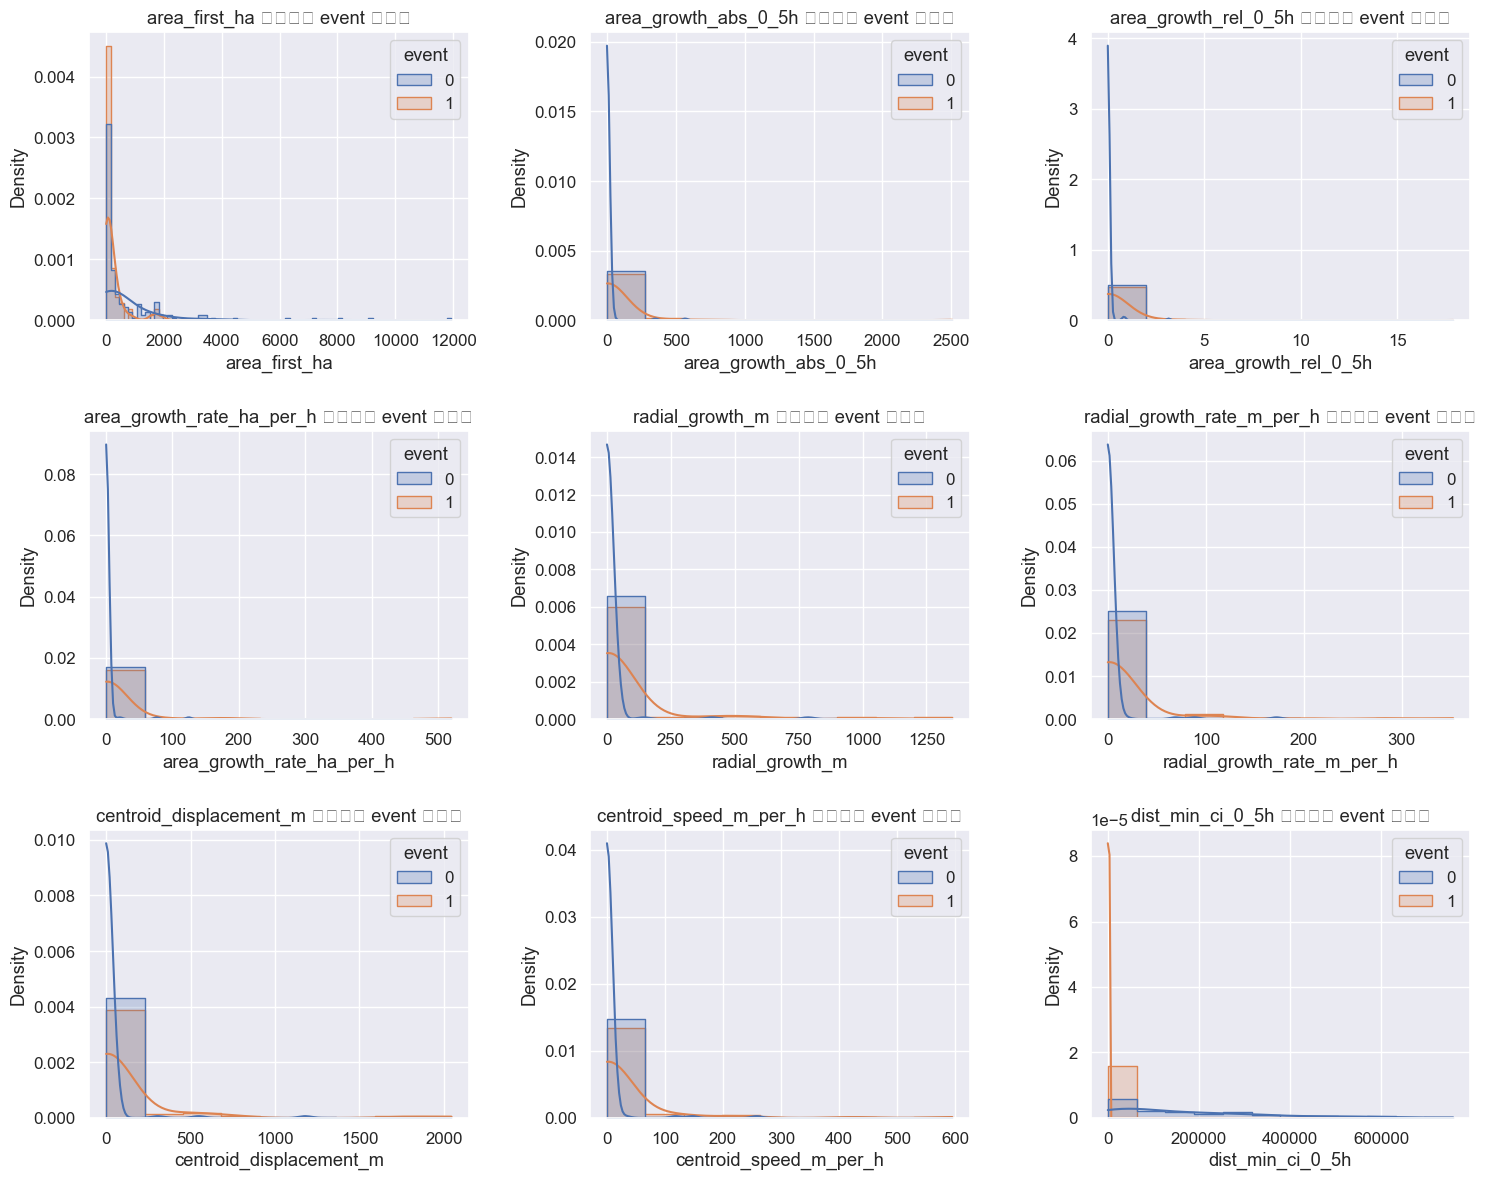

In [7]:
# 画出0-5小时特征的直方图，并按 event 分颜色
import math

if 'event' in train_df.columns:
    num_features = len(early_features)
    num_cols = 3
    num_rows = math.ceil(num_features / num_cols)
    fig, axes = plt.subplots(num_rows, num_cols, figsize=(5 * num_cols, 4 * num_rows))
    axes = axes.flatten()

    for idx, feature in enumerate(early_features):
        ax = axes[idx]
        sns.histplot(
            data=train_df,
            x=feature,
            hue='event',
            stat='density',
            common_norm=False,
            element='step',
            kde=True,
            ax=ax
        )
        ax.set_title(f'{feature} 分布（按 event 分组）')

    # 删除多余子图轴
    for extra_ax in axes[num_features:]:
        fig.delaxes(extra_ax)

    plt.tight_layout()
else:
    print('警告：数据中不存在 event 列，无法画按事件分组的分布图。')

## 2. D 新增四个特征与火灾蔓延关系

D 新构建的四个特征为：
- `projected_time_to_threat`：根据当前质心速度与最近社区距离估算的威胁时间；
- `kinetic_momentum`：面积增长率与距离加速度的组合，反映“动能动量”；
- `directed_speed_vector`：沿威胁方向的分速度（对齐度 × 质心速度）；
- `initial_vigor_index`：初始面积与初始增长量的组合指标。

下面对它们的分布、与 `event` 和 `time_to_hit_hours` 的关系做EDA。

In [8]:
# D 新增的四个特征
new_features = [
    'projected_time_to_threat',
    'kinetic_momentum',
    'directed_speed_vector',
    'initial_vigor_index'
]

new_features = [col for col in new_features if col in train_df.columns]
print('实际存在的新特征:', new_features)

# 描述性统计
new_desc = train_df[new_features].describe().T
display(new_desc)

# 与 event / time_to_hit_hours 的线性相关系数
corr_records = []
for feature in new_features:
    record = {'feature': feature}
    if 'event' in train_df.columns:
        corr_ev = train_df[[feature, 'event']].corr(numeric_only=True).iloc[0, 1]
        record['corr_with_event'] = corr_ev
    if 'time_to_hit_hours' in train_df.columns:
        corr_th = train_df[[feature, 'time_to_hit_hours']].corr(numeric_only=True).iloc[0, 1]
        record['corr_with_time_to_hit_hours'] = corr_th
    corr_records.append(record)

corr_summary = pd.DataFrame(corr_records)
display(corr_summary)

实际存在的新特征: ['projected_time_to_threat', 'kinetic_momentum', 'directed_speed_vector', 'initial_vigor_index']


,count,mean,std,min,25%,50%,75%,max
projected_time_to_threat,221.0,1.209666e+11,1.703112e+11,1.083822,2.577970e+09,2.805754e+10,1.961168e+11,7.577005e+11
kinetic_momentum,221.0,-3.231775e+02,4.127954e+03,-60854.043504,0.000000e+00,0.000000e+00,0.000000e+00,2.171574e+03
directed_speed_vector,221.0,5.516897e-01,4.676065e+01,-526.597241,0.000000e+00,0.000000e+00,0.000000e+00,3.830992e+02
initial_vigor_index,221.0,1.952841e+00,7.392938e+00,0.000000,0.000000e+00,0.000000e+00,0.000000e+00,5.790264e+01


,feature,corr_with_event,corr_with_time_to_hit_hours
0,projected_time_to_threat,-0.472636,0.338159
1,kinetic_momentum,-0.104523,0.114817
2,directed_speed_vector,0.008147,-0.023527
3,initial_vigor_index,0.267875,-0.297278


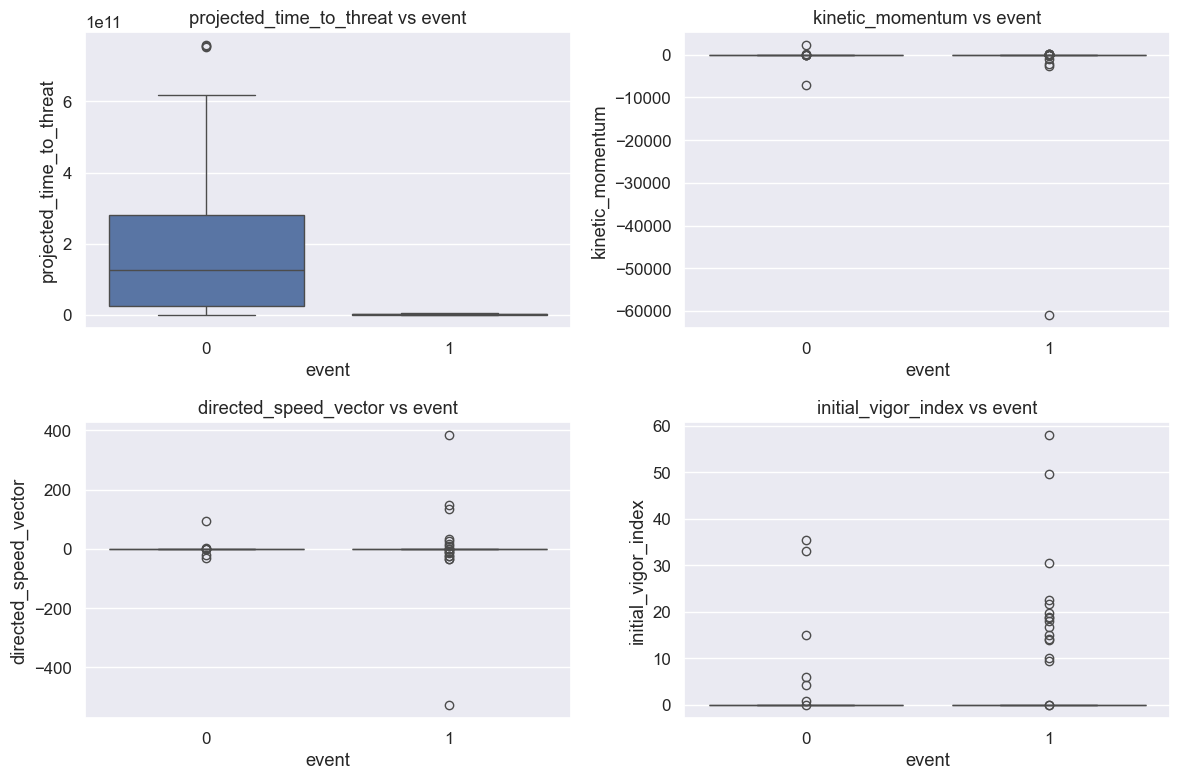

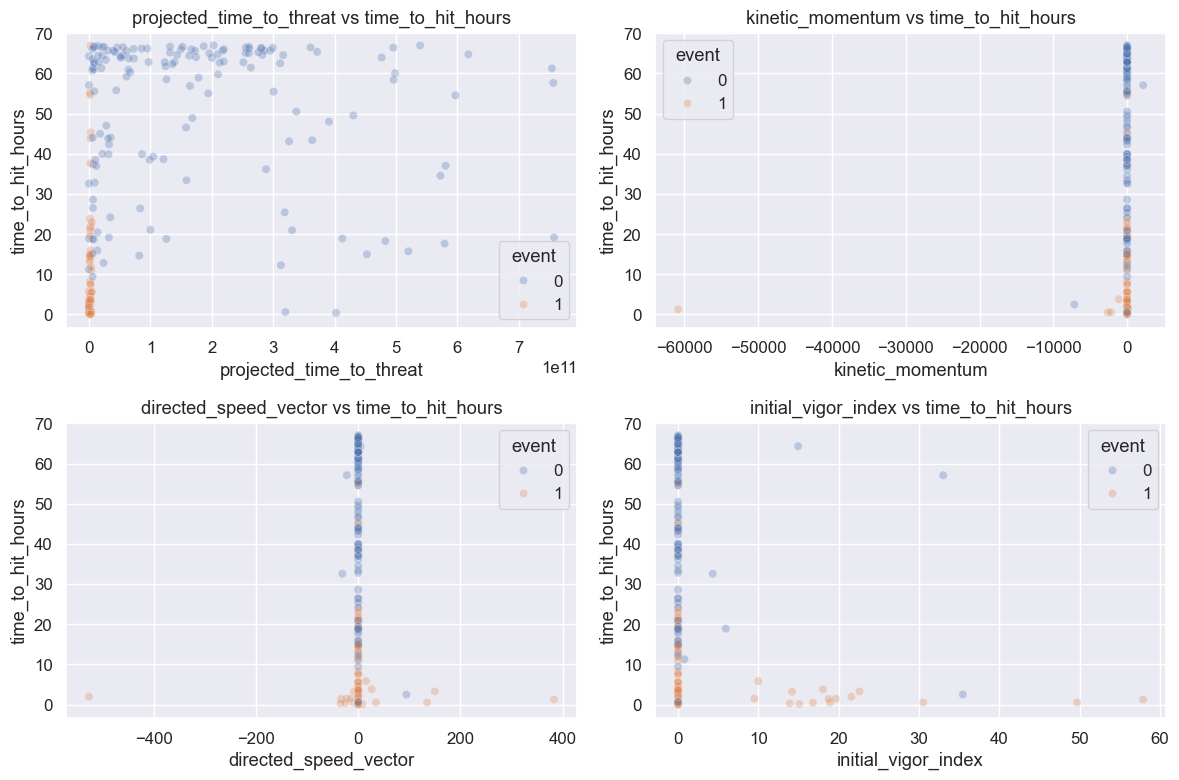

In [9]:
# 新特征按 event 的箱线图，可直观看出正负样本的差异
if 'event' in train_df.columns and len(new_features) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    for idx, feature in enumerate(new_features):
        ax = axes[idx]
        sns.boxplot(data=train_df, x='event', y=feature, ax=ax)
        ax.set_title(f'{feature} vs event')

    # 删除多余子图轴
    for extra_ax in axes[len(new_features):]:
        fig.delaxes(extra_ax)

    plt.tight_layout()
else:
    print('无法画箱线图：缺少 event 列或新特征列。')

# 新特征与 time_to_hit_hours 的散点图，观察与时间标签的关系
if 'time_to_hit_hours' in train_df.columns and len(new_features) > 0:
    fig, axes = plt.subplots(2, 2, figsize=(12, 8))
    axes = axes.flatten()
    for idx, feature in enumerate(new_features):
        ax = axes[idx]
        sns.scatterplot(
            data=train_df,
            x=feature,
            y='time_to_hit_hours',
            hue='event' if 'event' in train_df.columns else None,
            alpha=0.3,
            ax=ax
        )
        ax.set_title(f'{feature} vs time_to_hit_hours')

    for extra_ax in axes[len(new_features):]:
        fig.delaxes(extra_ax)

    plt.tight_layout()
else:
    print('无法画散点图：缺少 time_to_hit_hours 列或新特征列。')

## 3. 特征数据质量检查（为C的建模做准备）

这一部分主要检查：
- 缺失值和无穷大值；
- 数值型/类别型字段的数据类型是否合理；
- 训练集与测试集的特征列是否完全一致（除去训练集多出来的标签列）。

In [10]:
def check_dataset_quality(dataframe: pd.DataFrame, name: str) -> None:
    """
    简单打印数据集的数据类型、缺失值和无穷大情况。
    """
    print(f'\n===== 数据集: {name} =====')
    print('数据类型：')
    print(dataframe.dtypes)

    missing = dataframe.isna().sum()
    missing = missing[missing > 0]
    if not missing.empty:
        print('存在缺失值的列：')
        print(missing)
    else:
        print('未发现缺失值。')

    numeric_cols = dataframe.select_dtypes(include=[np.number]).columns
    inf_counts = np.isinf(dataframe[numeric_cols]).sum()
    inf_counts = inf_counts[inf_counts > 0]
    if not inf_counts.empty:
        print('存在无穷大值的列：')
        print(inf_counts)
    else:
        print('未发现无穷大值。')

# 分别检查训练集和测试集
check_dataset_quality(train_df, 'train_augmented_D')
check_dataset_quality(test_df, 'test_augmented_D')

# 检查特征列是否一致（忽略训练集的标签列）
label_cols = {'event', 'time_to_hit_hours'} & set(train_df.columns)
feature_cols_train = [col for col in train_df.columns if col not in label_cols]
feature_cols_test = list(test_df.columns)

set_train = set(feature_cols_train)
set_test = set(feature_cols_test)

print('训练集特征列数量:', len(set_train))
print('测试集特征列数量:', len(set_test))
print('特征列是否完全一致:', set_train == set_test)
print('只在训练集中的特征列:', sorted(set_train - set_test))
print('只在测试集中的特征列:', sorted(set_test - set_train))


===== 数据集: train_augmented_D =====
数据类型：
event_id                          int64
num_perimeters_0_5h               int64
dt_first_last_0_5h              float64
low_temporal_resolution_0_5h      int64
area_first_ha                   float64
area_growth_abs_0_5h            float64
area_growth_rel_0_5h            float64
area_growth_rate_ha_per_h       float64
log1p_area_first                float64
log1p_growth                    float64
log_area_ratio_0_5h             float64
relative_growth_0_5h            float64
radial_growth_m                 float64
radial_growth_rate_m_per_h      float64
centroid_displacement_m         float64
centroid_speed_m_per_h          float64
spread_bearing_deg              float64
spread_bearing_sin              float64
spread_bearing_cos              float64
dist_min_ci_0_5h                float64
dist_std_ci_0_5h                float64
dist_change_ci_0_5h             float64
dist_slope_ci_0_5h              float64
closing_speed_m_per_h           float6

## 4. 为A和C导出可直接使用的汇总结果

这一部分将若干关键统计结果保存为 CSV 文件，便于：
- A 直接引用到报告和 PPT 中；
- C 在建模前快速浏览特征与标签之间的关系。

In [12]:
output_dir = 'data'  # 直接复用第二周 data 目录

# 4.1 0-5小时核心特征按 event 分组的统计汇总
if 'event' in train_df.columns and len(early_features) > 0:
    early_stats_by_event = train_df.groupby('event')[early_features].agg(['mean', 'std', 'median'])
    early_stats_by_event.to_csv(f'{output_dir}/B_early_features_by_event_summary.csv')
    print('已保存: B_early_features_by_event_summary.csv')

# 4.2 D 新特征与标签的相关系数表
if len(new_features) > 0:
    corr_rows = []
    for feature in new_features:
        row = {'feature': feature}
        if 'event' in train_df.columns:
            row['corr_with_event'] = train_df[[feature, 'event']].corr(numeric_only=True).iloc[0, 1]
        if 'time_to_hit_hours' in train_df.columns:
            row['corr_with_time_to_hit_hours'] = train_df[[feature, 'time_to_hit_hours']].corr(numeric_only=True).iloc[0, 1]
        corr_rows.append(row)
    corr_table = pd.DataFrame(corr_rows)
    corr_table.to_csv(f'{output_dir}/B_new_features_correlations.csv', index=False)
    print('已保存: B_new_features_correlations.csv')

# 4.3 各特征按分位数分箱后的正例率表（用于画 PPT 梯度条形图）
def compute_event_rate_by_quantile(dataframe: pd.DataFrame, feature: str, num_quantiles: int = 4) -> pd.DataFrame:
    if feature not in dataframe.columns:
        raise ValueError(f'列 {feature} 不存在')
    if 'event' not in dataframe.columns:
        raise ValueError('数据集中不存在 event 列')
    # 分位数分箱，duplicates='drop' 可以处理常数列的情况
    bins = pd.qcut(dataframe[feature], q=num_quantiles, duplicates='drop')
    result = dataframe.groupby(bins, observed=False)['event'].mean().reset_index()
    result.columns = ['bin', 'event_rate']
    result['feature'] = feature
    return result

event_rate_frames = []
if 'event' in train_df.columns:
    features_for_bins = early_features + new_features
    for feature_name in features_for_bins:
        try:
            frame = compute_event_rate_by_quantile(train_df, feature_name, num_quantiles=4)
            event_rate_frames.append(frame)
        except Exception as error:
            print(f'按分位数统计 {feature_name} 时出错: {error}')

if len(event_rate_frames) > 0:
    event_rate_table = pd.concat(event_rate_frames, ignore_index=True)
    event_rate_table.to_csv(f'{output_dir}/B_feature_event_rate_by_quantile.csv', index=False)
    print('已保存: B_feature_event_rate_by_quantile.csv')
else:
    print('未能成功生成分位数正例率表。')

已保存: B_early_features_by_event_summary.csv
已保存: B_new_features_correlations.csv
已保存: B_feature_event_rate_by_quantile.csv


## 5. 小结（供A写报告/PPT时参考)

基于以上 EDA 与特征数据质量检查的结果，得出以下核心结论：

**1. 0-5小时原特征在正负样本（发生威胁 vs 未发生威胁）之间的差异：**
- **面积扩张速率**（`area_growth_abs_0_5h`, `area_growth_rate_ha_per_h`）以及 **距离移动变动**（`centroid_displacement_m`, `radial_growth_m`）在**正样本（发生社区威胁）中明显更大**，反映出有威胁的火灾在早期表现出了更高的扩张与移动活性。
- **初始火场与社区的距离**（`dist_min_ci_0_5h`）：正样本由于距离社区极近（平均数在 2.3 公里左右），而负样本平均距离远（约高达 179 公里），因此它是极其重要的基础区分特征。

**2. D 新增四个特征的作用与相关性：**
- **`projected_time_to_threat` (预期威胁时间)**：该特征与 `event` 有显著的**负相关性（约 -0.47）**，表现出最强的单变量区分度：威胁时间越短，越容易发生紧急威胁（event=1）。
- **`initial_vigor_index` (初始活力指数)**：与 `event` 的正相关性较强（约 0.27），表明火源起始越活跃，产生威胁的倾向越高。与 `time_to_hit_hours` 的负相关性（-0.30）也表明威力越大、到达时间可能越短。
- 但是，新特征中存在大量 `0` 值（因为观测静态样本非常多），以及极端的异常大值（如 `projected_time_to_threat` 带有千亿级别的极大值，因为有很多不移动的火场会导致速度分母极小而使得结果畸大）。

**3. 数据质量与建模建议：**
- 整体训练集合并入这四个高级特征后未发现缺失值，但是存在**严重偏态和极大稀疏点**的情况。
- 绝不可以不加处理就灌入对异常数值非常敏感的线性模型和神经网络（例如普通的 Cox 模型或 DeepSurv）。
- **后续建模建议（For C）**：基于这批特征的属性分布，我们 **强烈推荐**在阶段二的建模中使用基于树分割的方法能够鲁棒处理稀疏与异常峰值的模型：例如 **Random Survival Forest (RSF)** 或 **XGBoost (Survival)**。